# System 03 - Stakeholder Objectives scheme

Draws the stakeholder -> objective -> design-variable scheme (cf. slide 85 of the design-principles lecture) and saves it as `stakeholder_objective_variable_scheme.png` next to this notebook.

**How it works**
- Every variable sits directly under one objective (straight vertical arrow); its other influences are drawn as diagonal arrows.
- The left-to-right order of the variables is found automatically (brute force) so that the arrows cross as little as possible. The labels x1...x5 are assigned left to right after that, so they always read in order - the printed line `labels:` shows which variable got which number.

**How to change the scheme:** edit the cells under *Content* (stakeholders, objectives, variables, influences) or *Layout*, then run all cells.


## Imports

In [1]:
from itertools import permutations
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch, FancyBboxPatch

## Content

`INFLUENCES` lists, per objective, the variables that influence it. Each variable needs to influence at least the objective it is placed under; if no valid placement exists the code raises an error.

In [2]:
# Colour-blind-safe (Okabe-Ito) - one colour per objective, used for its box and incoming arrows
COLORS = {
    'cost':    '#E69F00',
    'plastic': '#009E73',
    'fishing': '#0072B2',
    'ecology': '#CC79A7',
    'health':  '#D55E00',
}

# (key, stakeholder name) - order = left-to-right order in the scheme
STAKEHOLDERS = [
    ('cost',    'INVESTORS /\nDONORS'),
    ('plastic', 'THE OCEAN\nCLEANUP'),
    ('fishing', 'NORTH PACIFIC\nCOMMERCIAL FISHERS'),
    ('ecology', 'MARINE CONSERVATION\nADVOCATES'),
    ('health',  'CITIZENS'),
]

# key -> objective name (quantity only; whether to min/max it is decided in the notebook)
OBJECTIVES = {
    'cost':    'COST',
    'plastic': 'PLASTIC\nREMOVAL',
    'fishing': 'FISHING-GROUND\nACCESS',
    'ecology': 'ECOLOGICAL\nIMPACT',
    'health':  'MICROPLASTIC\nREMOVAL',
}

# key -> (name, unit). The x1..x5 labels in the figure are assigned left to right after the
# layout is optimised, so they always read in order.
VARIABLES = {
    'depth':   ('SKIRT\nDEPTH', 'm'),
    'mesh':    ('MESH\nSIZE', 'mm'),
    'spacing': ('VESSEL\nSPACING', 'm'),
    'speed':   ('TOWING\nSPEED', 'm/s'),
    'systems': ('NUMBER OF\nSYSTEMS', '-'),
}

# objective -> variables that influence it (overlaps between objectives are intended)
INFLUENCES = {
    'cost':    ['depth', 'spacing', 'speed', 'systems'],
    'plastic': ['depth', 'spacing', 'speed', 'systems'],
    'fishing': ['spacing', 'systems'],
    'ecology': ['depth', 'mesh', 'speed', 'systems'],
    'health':  ['mesh', 'spacing', 'speed', 'systems'],
}

## Layout and arrow routing

In [3]:
# ---------------------------------------------------------------- layout
BOX_W, BOX_H = 18.0, 9.0
OBJ_H = 10.0
Y_STAKE, Y_OBJ, Y_VAR = 52, 34, 8
COL_X = [28 + 20 * i for i in range(5)]  # x-centre of each column (objectives and variables share columns)
Y_VAR_TOP = Y_VAR + BOX_H / 2
Y_OBJ_BOT = Y_OBJ - OBJ_H / 2
MAX_OFFSET = BOX_W / 2 - 1.5  # how far from a box centre an arrow may attach


def side_offsets(others):
    """Attachment offsets (relative to box centre) for arrows to/from `others`.

    `others` = list of (column_distance_sign_key, arrow_id) sorted by column. Arrows going left attach
    on the left half, arrows going right on the right half, farthest partner farthest out, so arrows
    from the same box do not cross each other. The straight (same-column) arrow attaches at the centre.
    """
    left = sorted([o for o in others if o[0] < 0])            # farthest (most negative) first
    right = sorted([o for o in others if o[0] > 0])           # nearest first
    step = min(3.0, MAX_OFFSET / max(len(left), len(right), 1))
    offs = {}
    for k, (_, aid) in enumerate(left):
        offs[aid] = -(len(left) - k) * step
    for k, (_, aid) in enumerate(right):
        offs[aid] = (k + 1) * step
    for d, aid in others:
        if d == 0:
            offs[aid] = 0.0
    return offs


def arrow_geometry(var_col):
    """var_col: {var_id: column}. Returns {(var, obj): ((x0, y0), (x1, y1))} for every influence arrow."""
    obj_col = {k: i for i, (k, _) in enumerate(STAKEHOLDERS)}
    start, end = {}, {}
    for v, cv in var_col.items():
        targets = [(obj_col[o] - cv, (v, o)) for o in obj_col if v in INFLUENCES[o]]
        for aid, off in side_offsets(targets).items():
            start[aid] = COL_X[cv] + off
    for o, co in obj_col.items():
        sources = [(var_col[v] - co, (v, o)) for v in INFLUENCES[o]]
        for aid, off in side_offsets(sources).items():
            end[aid] = COL_X[co] + off
    return {aid: ((start[aid], Y_VAR_TOP), (end[aid], Y_OBJ_BOT)) for aid in start}


def _ccw(a, b, c):
    return (c[1] - a[1]) * (b[0] - a[0]) - (b[1] - a[1]) * (c[0] - a[0])


def _cross(s1, s2):
    (a, b), (c, d) = s1, s2
    return _ccw(a, c, d) * _ccw(b, c, d) < 0 and _ccw(a, b, c) * _ccw(a, b, d) < 0


def count_crossings(var_col):
    segs = list(arrow_geometry(var_col).values())
    return sum(_cross(segs[i], segs[j]) for i in range(len(segs)) for j in range(i + 1, len(segs)))


def best_order():
    """Column for each variable: each variable must sit under an objective it influences (straight arrow);
    among those assignments pick the fewest crossings, then the least total sideways travel."""
    obj_keys = [k for k, _ in STAKEHOLDERS]
    var_ids = list(VARIABLES)
    best = None
    for perm in permutations(var_ids):  # perm[col] = variable placed in that column
        if any(perm[c] not in INFLUENCES[obj_keys[c]] for c in range(len(perm))):
            continue
        var_col = {v: c for c, v in enumerate(perm)}
        travel = sum(abs(var_col[v] - obj_keys.index(o)) for o in obj_keys for v in INFLUENCES[o])
        score = (count_crossings(var_col), travel)
        if best is None or score < best[0]:
            best = (score, var_col)
    if best is None:
        raise ValueError('No one-to-one placement of variables under objectives is possible with these INFLUENCES.')
    return best

## Drawing

In [4]:
def box(ax, cx, cy, w, h, text, fc, ec='black', tc='black', fs=9.5, weight='bold'):
    ax.add_patch(FancyBboxPatch((cx - w / 2, cy - h / 2), w, h, boxstyle='round,pad=0.02,rounding_size=0.8',
                                fc=fc, ec=ec, lw=1.3, zorder=3))
    ax.text(cx, cy, text, ha='center', va='center', fontsize=fs, color=tc, weight=weight,
            zorder=4, linespacing=1.25)


def main():
    (crossings, _), var_col = best_order()
    order = sorted(var_col, key=var_col.get)
    print('crossings:', crossings)
    print('labels:', ', '.join(f'x{i + 1} = {v}' for i, v in enumerate(order)))

    fig, ax = plt.subplots(figsize=(15, 7.6))
    ax.set_xlim(0, 118)
    ax.set_ylim(2, 60)
    ax.axis('off')

    # row labels (underlined, as on the slide)
    for label, y in (('STAKEHOLDER', Y_STAKE), ('OBJECTIVES', Y_OBJ), ('VARIABLES', Y_VAR)):
        ax.text(1, y, label, fontsize=11, weight='bold', va='center')
        ax.plot([1, 15], [y - 2.2, y - 2.2], color='black', lw=1.2)

    # variable -> objective arrows (drawn first so the boxes sit on top)
    for (v, o), (p0, p1) in arrow_geometry(var_col).items():
        ax.add_patch(FancyArrowPatch(p0, p1, arrowstyle='-|>', mutation_scale=8, color=COLORS[o],
                                     lw=1.6, alpha=0.95, zorder=2, shrinkA=0, shrinkB=0))

    # stakeholder boxes, stakeholder -> objective arrows, objective boxes
    for (key, name), cx in zip(STAKEHOLDERS, COL_X):
        box(ax, cx, Y_STAKE, BOX_W, 8.0, name, fc='white', fs=9)
        ax.add_patch(FancyArrowPatch((cx, Y_STAKE - 4.0), (cx, Y_OBJ + OBJ_H / 2), arrowstyle='-|>',
                                     mutation_scale=8, color='black', lw=1.6, zorder=2, shrinkA=0, shrinkB=0))
        tc = 'black' if key == 'cost' else 'white'  # white on yellow is hard to read
        box(ax, cx, Y_OBJ, BOX_W, OBJ_H, OBJECTIVES[key], fc=COLORS[key], tc=tc, fs=10)

    # variable boxes
    for v, c in var_col.items():
        name, unit = VARIABLES[v]
        box(ax, COL_X[c], Y_VAR, BOX_W, BOX_H, f'{name}\n(x{c + 1}) [{unit}]', fc='white', fs=9)

    ax.set_title('System 03 -  Stakeholder Objectives', fontsize=20, weight='bold')

    out = Path('stakeholder_objective_variable_scheme.png')  # saved next to this notebook
    fig.savefig(out, dpi=200, bbox_inches='tight', facecolor='white')
    plt.show()
    print('saved', out.resolve())

## Run

crossings: 35
labels: x1 = depth, x2 = spacing, x3 = systems, x4 = speed, x5 = mesh


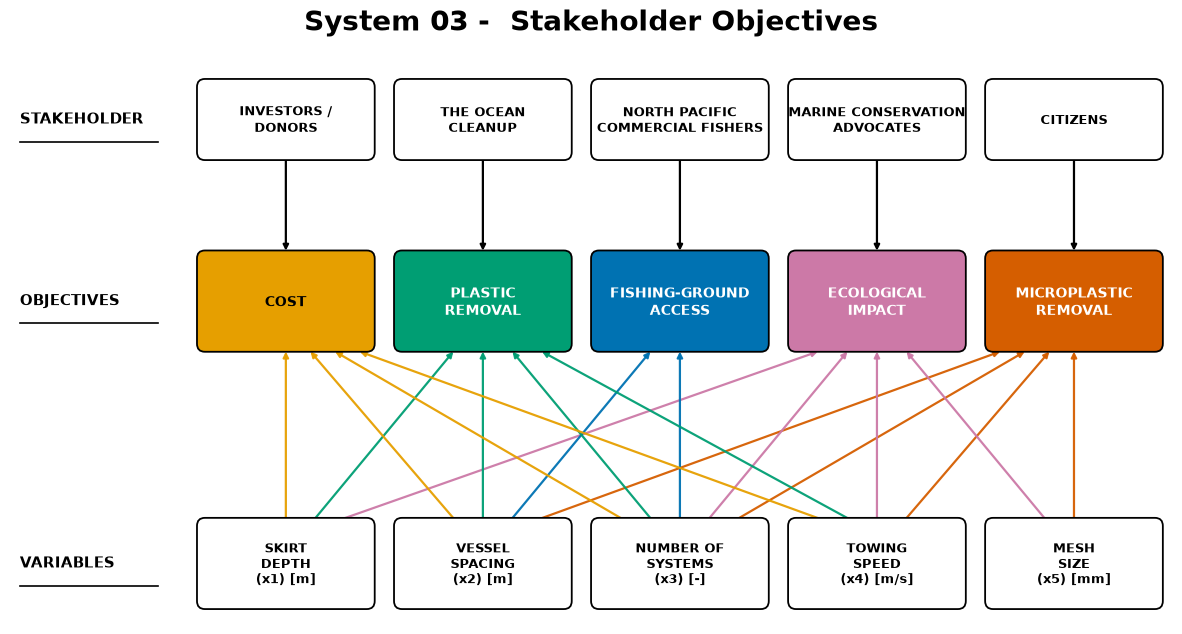

saved C:\Users\leolo\OneDrive\Desktop\CE_Master_TUDelft\Q1\Interdisciplinary\UNIT1_Design\-The_Ocean_CleanUp_System_03-\Our project\stakeholder_objective_variable_scheme.png


In [5]:
main()